# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [2]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

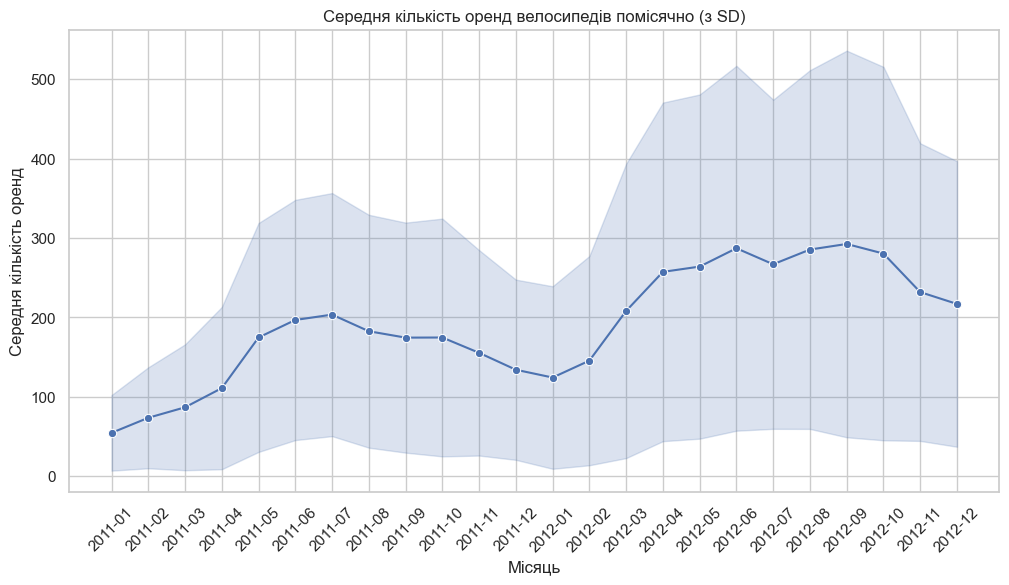

In [9]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    marker='o',
    errorbar=('sd', 1)     
)

plt.title("Середня кількість оренд велосипедів помісячно (з SD)")
plt.xlabel("Місяць")
plt.ylabel("Середня кількість оренд")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

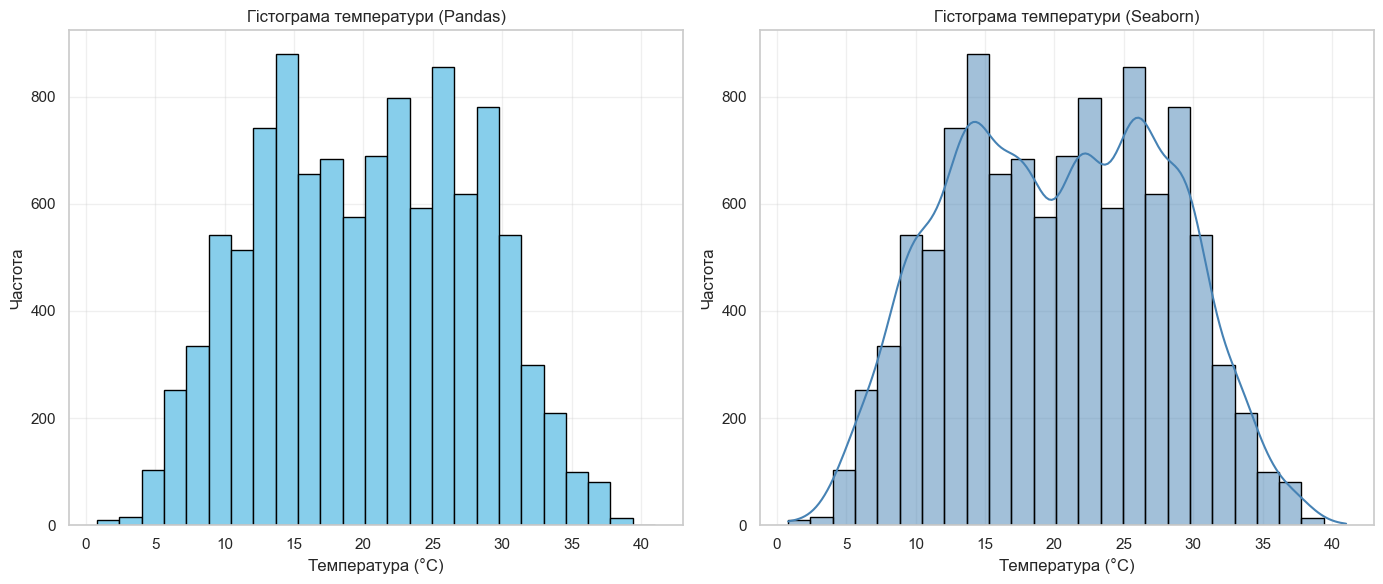

In [11]:

plt.figure(figsize=(14,6))

bins = 25   

# 1. Pandas histogram 
plt.subplot(1,2,1)
df['temp'].plot(kind='hist', bins=bins, color='skyblue', edgecolor='black')
plt.title('Гістограма температури (Pandas)')
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)

# 2. Seaborn histogram + KDE
plt.subplot(1,2,2)
sns.histplot(df['temp'], bins=bins, kde=True, color='steelblue', edgecolor='black')
plt.title('Гістограма температури (Seaborn)')
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Якшо чесно, візуально різниця, окрім цієї лінії, не бачу. KDE - це плавна крива, яка показує, як розподілені дані, але без різких “сходинок” як у гістограмі.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [12]:
#weather_map = {
    #1: "Ясно",
    #2: "Туман",
   # 3: "Легкий дощ",
   # 4: "Сильний дощ"
#}

#df['weather_label'] = df['weather'].map(weather_map)

In [18]:
order = ["Ясно", "Туман", "Легкий дощ", "Сильний дощ"]

df["weather_label"] = pd.Categorical(df["weather_label"], categories=order, ordered=True)

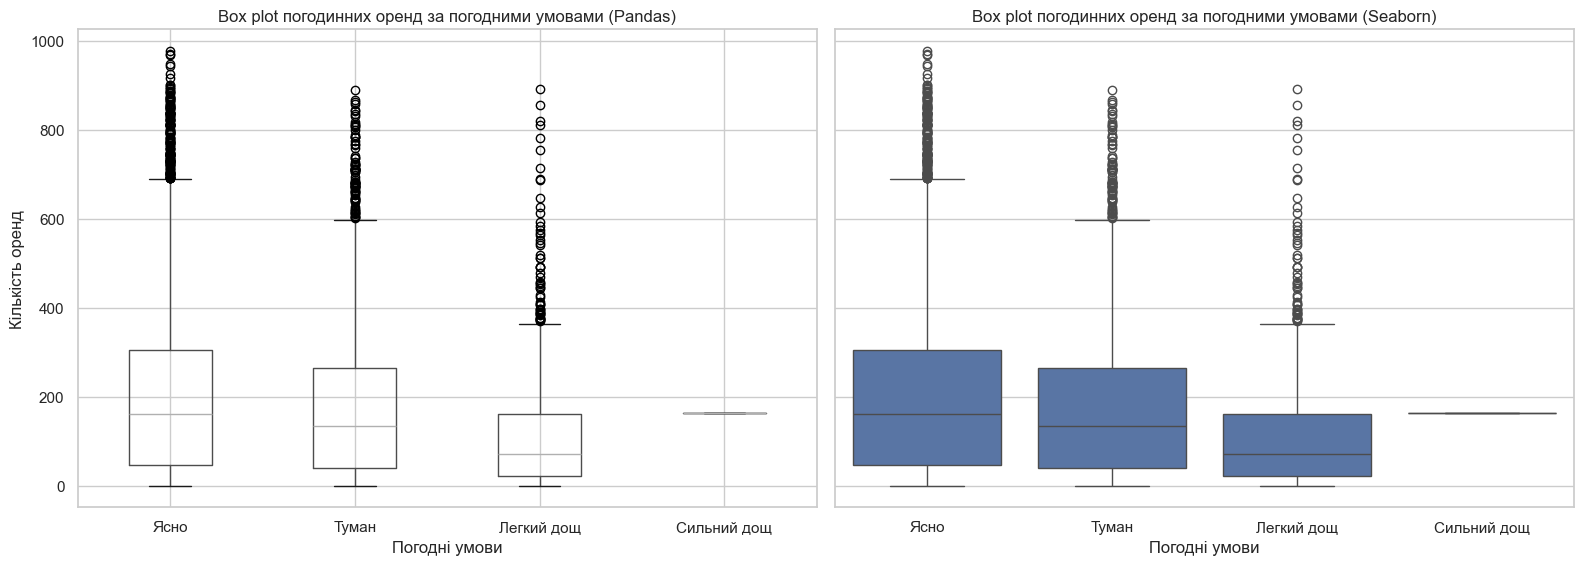

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Ліворуч: Pandas boxplot
df.boxplot(
    column='count',
    by='weather_label',
    grid=True,
    ax=axes[0]           
)

axes[0].set_title("Box plot погодинних оренд за погодними умовами (Pandas)")
axes[0].set_xlabel("Погодні умови")
axes[0].set_ylabel("Кількість оренд")

fig.suptitle("")

# Праворуч: Seaborn boxplot 
sns.boxplot(
    data=df,
    x='weather_label',
    y='count',
    ax=axes[1]           
)

axes[1].set_title("Box plot погодинних оренд за погодними умовами (Seaborn)")
axes[1].set_xlabel("Погодні умови")
axes[1].set_ylabel("Кількість оренд")

plt.tight_layout()
plt.show()

В Pandas коробки виглядають ніби "стиснутими", "вужчими", ніж в Seaborn. Також відрізняється базові кольорові налаштування

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


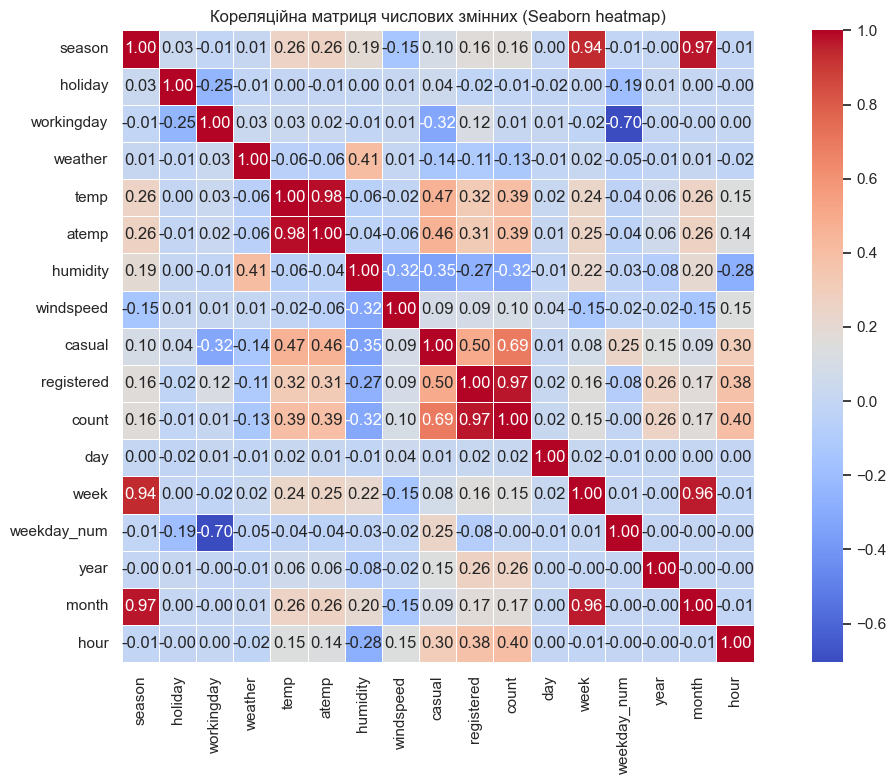

In [21]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,     
    fmt=".2f",      
    cmap="coolwarm", 
    linewidths=0.5,  
    square=True
)

plt.title("Кореляційна матриця числових змінних (Seaborn heatmap)")
plt.tight_layout()
plt.show()

1. Найвища позитивна кореляція з count:
registered	0.97 → найбільший внесок, зареєстровані користувачі = основа попиту
casual	~0.69 → логічно: хороша погода → більше випадкових поїздок
temp	~0.39
atemp	~0.31
year	~0.17 → з кожним роком попит зростає
month	~0.17 → сезонність
2. temp : atemp ≈ 0.98 (дуже висока кореляція)
temp — реальна температура повітря
atemp — температура, що “відчувається” (wind chill, humidity, etc.)
У звичайних умовах вони майже однакові:
людина відчуває температуру близькою до фактичної, за винятком сильного вітру чи вологості.
3. working day : weekday_num -0.70 (структурна особливість)
working day : holiday -0.25 (вихідні не лише на свята, а і в інші дні)
working day : casual -0.32 (в будні дні поїздок менше, аніж в вихідні)
humidity : windspeed -0.32 (особливості метеорології: при вітрі вологість нижча)
humidity : casual - 0.35 (менше бажаючих кататися при високій вологості)
humidity : registered -0.27 
humidity : count - 0.32 
humidity : hour -0.28 ( ночні годині ведикі по вологості)

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


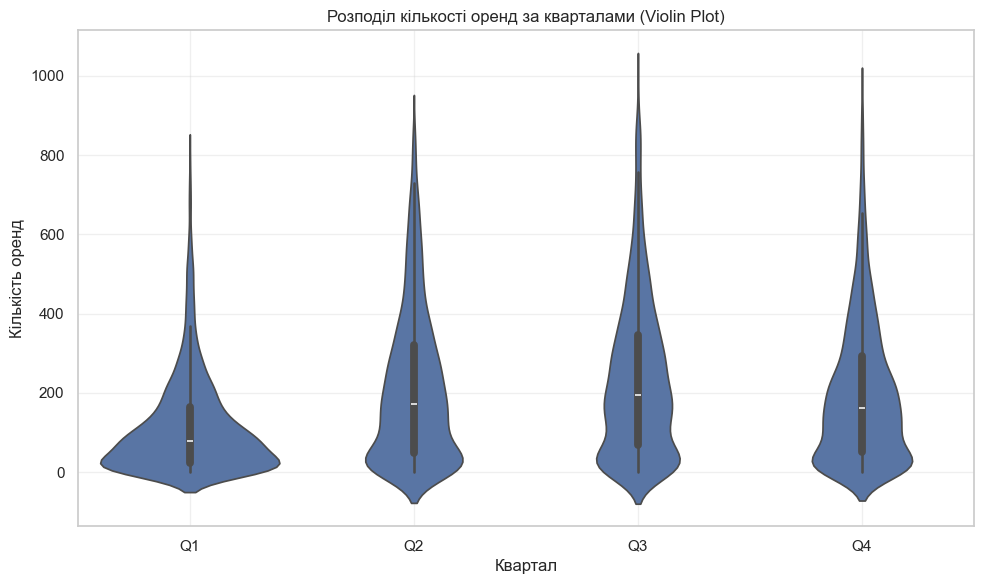

In [24]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='season',
    y='count'
)

plt.title("Розподіл кількості оренд за кварталами (Violin Plot)")
plt.xlabel("Квартал")
plt.ylabel("Кількість оренд")

# Підписи кварталів
plt.xticks([0,1,2,3], ["Q1", "Q2", "Q3", "Q4"])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1. Товщина “скрипки” = густота значень (де багато оренд, там ширше).
2. Найбільша варіабельність у Q3:
"Скрипка" у Q3 найвища → максимальні піки оренд;
вона ширша по всій висоті → дані сильно розкидані;
довгий "хвіст" зверху → бувають дні/години з дуже високим попитом.
3. Violin plot показує форму розподілу (густину), а не лише статистичні межі.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

<Figure size 1200x1000 with 0 Axes>

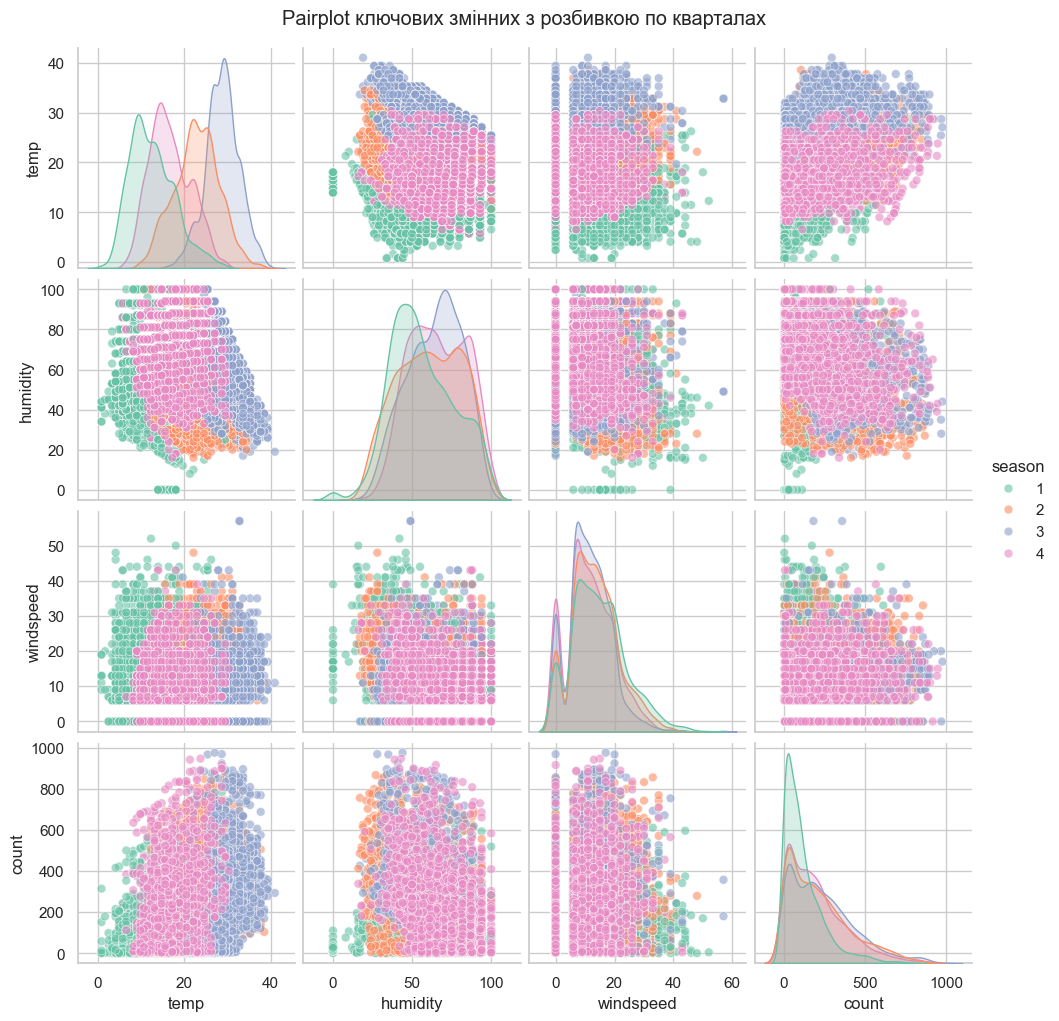

In [28]:
cols = ['temp', 'humidity', 'windspeed', 'count', 'season']
df.sample(frac=0.2)
plt.figure(figsize=(12, 10))

sns.pairplot(
    df[cols],
    hue='season',
    palette='Set2',
    diag_kind='kde',   # KDE на діагоналі
    plot_kws={'alpha': 0.6, 's': 40}  # красивіші точки
)

plt.suptitle("Pairplot ключових змінних з розбивкою по кварталах", y=1.02)
plt.show()

1. Між якими змінними найсильніший лінійний зв’язок?
temp : count 

Це видно з нижнього лівого або верхнього правого трикутника : точки формують чіткі смуги. Це класичний патерн: 
чим тепліше — тим більше люди орендують велосипеди.

Додаткові менш сильні, але помітні зв’язки:
humidity → count (негативний) : чим більше вологості → тим менше поїздок

temp → humidity (негативний) : теплі дні зазвичай суші

humidity → casual/registered (негативний)

2. Яка характеристика найбільше відрізняється між кварталами?
Температура (temp)

На діагоналі KDE видно: Q1: низькі температури; Q2: ростуть; Q3: пік сезону, найтепліші значення; Q4: спад назад

Тобто кожен квартал має повністю різний температурний профіль.

Але є ще дві характеристики, які теж помітно змінюються:
humidity (вологість): 
у Q1 та Q4 вологість вища (холодні сезони); 
у Q2–Q3 розподіл зміщується вниз (сухіші літні місяці)

count (кількість оренд)
Сильно залежить від сезону:
Q1 — дуже низькі оренди; Q2 — сильний підйом; Q3 — максимальний пік; Q4 — спад;

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

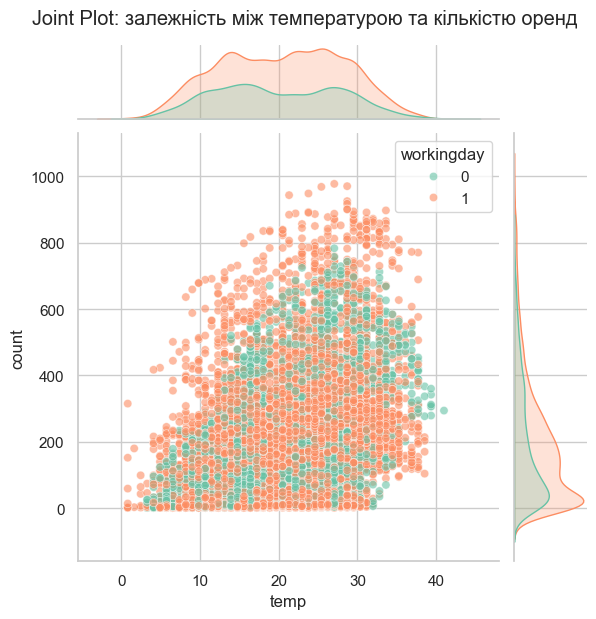

In [33]:
sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='workingday',
    kind='scatter',        # scatter + KDE на діагоналях
    palette='Set2',
    alpha=0.6
)

plt.suptitle("Joint Plot: залежність між температурою та кількістю оренд", y=1.03)
plt.show();

1. У jointplot є:
центральний scatterplot → залежність temp → count
верхній графік → розподіл temp
правий графік → розподіл count